# 04 · Camada analítica: temas, frequências e evidências

**Problema que esta camada resolve.** As perguntas de exemplo do enunciado são, em sua maioria, *agregadas*: "principais problemas", "com maior frequência", "padrões recorrentes". Um RAG puro entrega ao LLM ~8 avaliações de ~42 mil — ele não tem como saber o que é frequente. Qualquer "a maioria dos clientes reclama de X" seria uma afirmação sem suporte, exatamente o que o requisito 4 proíbe.

**Solução.** Separar quem **conta** de quem **redige**:
1. uma **taxonomia de temas** auditável rotula todas as avaliações (regras léxicas, `src/voc_rag/themes.py`);
2. o código calcula as **frequências** sobre o recorte pedido (filtros de nota, período, categoria, UF, entrega);
3. o RAG recupera **exemplares** de cada tema (busca híbrida + reranker, restrita ao tema);
4. o LLM redige a síntese **copiando os números da tabela** e citando os exemplos — e a verificação pós-geração remove qualquer linha com número fora da tabela.

Este notebook mostra (a) como a taxonomia foi derivada dos dados, (b) sua cobertura e precisão, (c) os insights que ela permite.

In [1]:
import os
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")  # saída limpa no GitHub (sem barras de progresso)
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Markdown
from voc_rag.config import get_settings, ROOT
from voc_rag.indexing import KnowledgeIndex
from voc_rag.themes import TAXONOMIA, NOTAS_PROBLEMA, NOTAS_ELOGIO
from voc_rag.text_utils import tokenize_lexical
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_colwidth", 100)
s = get_settings()
k = KnowledgeIndex.load(s)
docs = k.docs
lab = pd.read_parquet(s.base_dir / "temas.parquet").drop(columns="review_id").astype(bool)
print("embeddings usados na descoberta:", k.meta["embedding_model"], "| documentos:", len(docs))

embeddings usados na descoberta: intfloat/multilingual-e5-base | documentos: 42138


## 1. Descoberta: que assuntos existem nas avaliações negativas?
Antes de escrever regras, agrupamos as avaliações de nota 1–3 (com mais de 3 palavras) por similaridade dos **embeddings** (K-Means) e listamos os termos característicos de cada grupo (termos sobre-representados no grupo em relação ao conjunto: tf_grupo × log(tf_grupo / tf_global)). A taxonomia foi escrita a partir desses grupos.

In [2]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer
neg = ((docs.review_score <= 3) & (~docs.texto_curto)).values
X = k.vectors[neg]; txt = docs.texto[neg].reset_index(drop=True)
km = KMeans(n_clusters=12, n_init=5, random_state=s.seed).fit(X)
grupos = pd.Series(km.labels_)
# c-TF-IDF
cv = CountVectorizer(tokenizer=tokenize_lexical, lowercase=False, token_pattern=None, min_df=5)
M = cv.fit_transform([" ".join(txt[grupos == g]) for g in range(12)]).toarray().astype(float)
tf = M / M.sum(axis=1, keepdims=True); tf_medio = M.sum(axis=0) / M.sum()
# termos SOBRE-representados no grupo: contribuição tipo KL = tf_g * log(tf_g / tf_global)
distintivo = tf * np.log(np.maximum(tf, 1e-12) / tf_medio)
vocab = np.array(cv.get_feature_names_out())
lab_neg = lab[neg].reset_index(drop=True)
linhas = []
for g in range(12):
    top = vocab[np.argsort(-distintivo[g])[:8]]
    dom = lab_neg[grupos == g].mean().sort_values(ascending=False)
    linhas.append({"grupo": g, "n": int((grupos == g).sum()), "termos característicos (stems)": ", ".join(top),
                   "tema dominante": f"{dom.index[0]} ({dom.iloc[0]:.0%})", "exemplo": txt[grupos == g].iloc[0][:90]})
pd.DataFrame(linhas).sort_values("n", ascending=False)

,grupo,n,termos característicos (stems),tema dominante,exemplo
9,9,2042,"entreg, praz, nao, aind, por, produt, mesm, dia",nao_recebido (26%),"Produto bom, porém o que veio para mim não condiz com a foto do anúncio."
1,1,1569,"entreg, correi, dia, dias, loj, cancel, praz, fret",nao_recebido (32%),"Sempre compro pela Internet e a entrega ocorre antes do prazo combinado, que acredito ser"
10,10,1441,"dia, compr, ped, agor, pagu, estou, quer, correi",nao_recebido (24%),EU NÃO RECEBI O PRODUTO E CONSTA NO SISTEMA QUE EU RECEBI ALÉM DE PAGAR CARO DO FRETE
4,4,1314,"nao, produt, aind, receb, entreg, demor, qualidad, avali",nao_recebido (33%),"Produto muito inferior, mal acabado."
7,7,1273,"nao, produt, receb, aind, entreg, aguard, estou, retorn",nao_recebido (44%),Não chegou meu produto. Péssimo
6,6,1256,"compr, not, apen, cartuch, dois, fiscal, vei, errad",incompleto (28%),recebi somente 1 controle Midea Split ESTILO. Faltou Controle Remoto para Ar Condicionado
0,0,1252,"qualidad, vei, fot, parec, bem, pessim, recom, material",insatisfacao_geral (32%),o acabento que estava na foto era bonito a que chegou foi de um sintetico feio com um acab
8,8,1088,"produt, entreg, demor, vei, praz, falt, aguard, cheg",atraso (12%),Demorou de mais pra entrega
3,3,603,"compr, apen, receb, dois, unidad, duas, soment, vei",incompleto (59%),Eu comprei duas unidades e só recebi uma e agora o que faço?
2,2,576,"nao, receb, produt, aind, cheg, entreg, moment, mercador",nao_recebido (84%),Nada de chegar o meu pedido.


> **Como ler.** Cada grupo deve corresponder a um ou mais temas da taxonomia; a coluna "tema dominante" mostra que fração do grupo as regras capturam. Grupos com tema dominante fraco apontam lacunas de cobertura (paráfrases não previstas ou queixas genéricas). Os grupos variam com o modelo de embeddings usado; a taxonomia, não — ela é fixa e auditável.

## 2. A taxonomia e sua cobertura

In [3]:
tax = pd.DataFrame([{"id": t.id, "tema": t.nome, "polaridade": t.polaridade, "grupo": t.grupo} for t in TAXONOMIA])
sc = docs.review_score
for pol, (lo, hi) in (("problema", NOTAS_PROBLEMA), ("elogio", NOTAS_ELOGIO)):
    base = (sc >= lo) & (sc <= hi); ids = tax[tax.polaridade == pol].id
    tax.loc[tax.polaridade == pol, "avaliacoes"] = [int(lab.loc[base, i].sum()) for i in ids]
    tax.loc[tax.polaridade == pol, "% da base"] = [round(lab.loc[base, i].mean() * 100, 1) for i in ids]
    print(f"{pol}: base = {base.sum():,} avaliações com texto (notas {lo}–{hi}); "
          f"cobertura (≥1 tema) = {lab.loc[base, ids].any(axis=1).mean():.1%}")
tax.sort_values(["polaridade", "avaliacoes"], ascending=[False, False])

problema: base = 14,445 avaliações com texto (notas 1–3); cobertura (≥1 tema) = 68.2%
elogio: base = 27,693 avaliações com texto (notas 4–5); cobertura (≥1 tema) = 79.0%


,id,tema,polaridade,grupo,avaliacoes,% da base
0,nao_recebido,Pedido não recebido,problema,entrega,3406.0,23.6
10,insatisfacao_geral,Não recomenda / insatisfação geral,problema,geral,1710.0,11.8
11,troca_reembolso,"Troca, devolução, cancelamento ou reembolso",problema,pos_venda,1704.0,11.8
2,incompleto,Pedido incompleto / faltando itens,problema,entrega,1484.0,10.3
1,atraso,Atraso na entrega,problema,entrega,1215.0,8.4
3,produto_errado,Produto errado / diferente do anunciado,problema,produto,759.0,5.3
13,transportadora,Transportadora / Correios,problema,entrega,739.0,5.1
8,atendimento_ruim,Atendimento / falta de resposta,problema,atendimento,718.0,5.0
4,danificado,Produto danificado / avariado,problema,produto,603.0,4.2
5,defeito,Defeito / não funciona,problema,produto,573.0,4.0


**Cobertura < 100% é esperada e declarada.** Avaliações sem tema são, em geral, genéricas ("não gostei", "regular") ou usam paráfrases não previstas. Toda resposta analítica informa a cobertura junto com os números.

## 3. Precisão das regras (auditoria amostral)

In [4]:
from voc_rag.evaluation import read_annotation_csv
aud_path = ROOT / "eval" / "auditoria_temas.csv"
aud = read_annotation_csv(aud_path)
# A amostra é sorteada uma vez e não é refeita (as anotações valem para ela). Se as regras
# mudaram depois do sorteio, avaliações que deixaram de ser rotuladas com o tema saem do cálculo:
# a precisão publicada é a das regras atuais.
rotulos = pd.DataFrame(lab.values, index=docs.review_id.values, columns=lab.columns)
aud["vigente"] = [bool(rotulos.at[r, t]) for r, t in zip(aud["review_id"], aud["tema"])]
a = aud[aud["correto"].str.strip().isin(["0", "1"]) & aud["vigente"]].copy()
if len(a):
    a["correto"] = a["correto"].astype(int)
    prec = a.groupby(["tema", "nome_do_tema"])["correto"].agg(["mean", "sum", "count"]).rename(columns={"mean": "precisao"}).round(3)
    print("anotador:", ", ".join(sorted(set(aud["anotador"]) - {""})) or "não informado",
          f"| linhas anotadas e vigentes: {len(a)} de {len(aud)} (fora do cálculo por mudança de regra: {int((~aud['vigente']).sum())})")
    display(prec.sort_values("precisao")); print(f"precisão geral: {a.correto.mean():.1%} ({a.correto.sum()}/{len(a)})")
else:
    print(f"Amostra de auditoria ainda não anotada: preencha a coluna 'correto' (1/0) em {aud_path.name}.")

anotador: Gustavo | linhas anotadas e vigentes: 314 de 315 (fora do cálculo por mudança de regra: 1)


,,precisao,sum,count
tema,nome_do_tema,,,
nao_recebido,Pedido não recebido,0.786,11,14
defeito,Defeito / não funciona,0.800,12,15
preco_bom,Preço / custo-benefício,0.800,12,15
atraso,Atraso na entrega,0.867,13,15
sem_estoque,Venda sem estoque / produto indisponível,0.867,13,15
danificado,Produto danificado / avariado,0.933,14,15
atendimento_ruim,Atendimento / falta de resposta,0.933,14,15
nota_fiscal,Nota fiscal,0.933,14,15
entrega_rapida,Entrega rápida / no prazo,1.000,15,15


precisão geral: 94.9% (298/314)


## 4. Insights: o que os clientes mais relatam

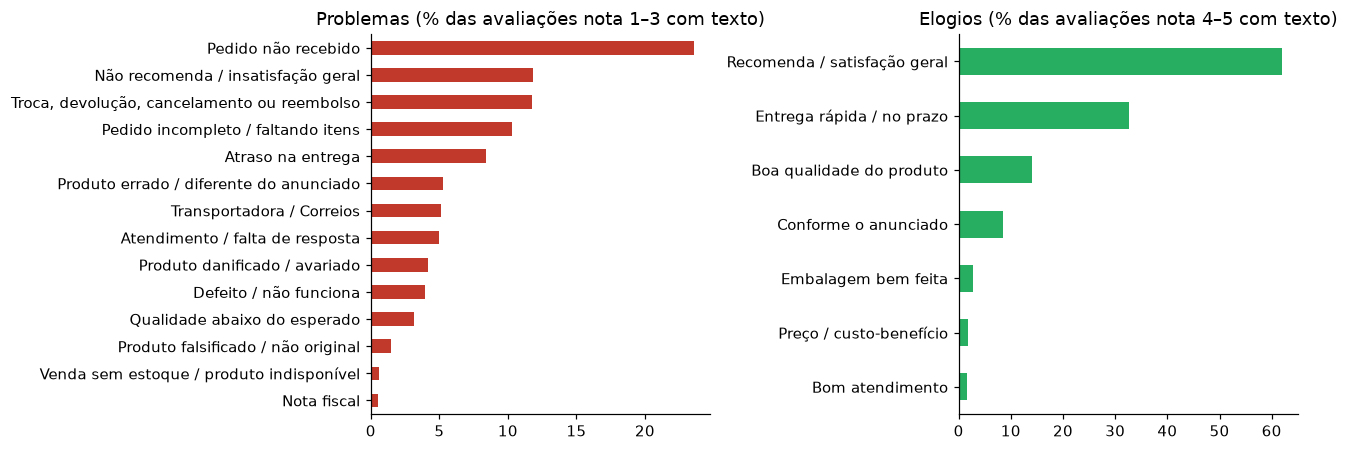

In [5]:
def ranking(pol):
    lo, hi = NOTAS_PROBLEMA if pol == "problema" else NOTAS_ELOGIO
    base = (sc >= lo) & (sc <= hi); ids = [t.id for t in TAXONOMIA if t.polaridade == pol]
    nomes = {t.id: t.nome for t in TAXONOMIA}
    return (lab.loc[base, ids].mean() * 100).rename(index=nomes).sort_values()
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ranking("problema").plot.barh(ax=ax[0], color="#c0392b"); ax[0].set_title("Problemas (% das avaliações nota 1–3 com texto)")
ranking("elogio").plot.barh(ax=ax[1], color="#27ae60"); ax[1].set_title("Elogios (% das avaliações nota 4–5 com texto)")
plt.tight_layout(); plt.show()

### 4.1 Problemas por categoria (as 8 categorias com mais avaliações negativas)

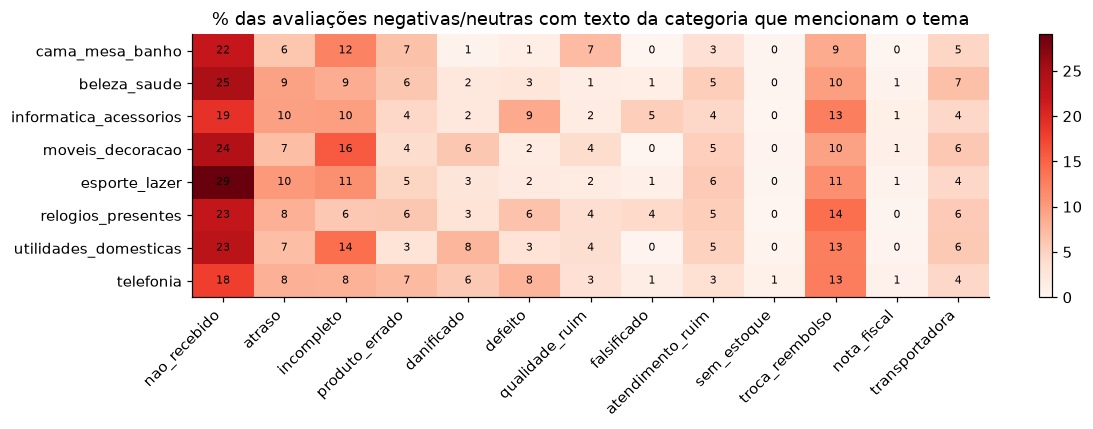

In [6]:
base = (sc <= 3)
probs = [t.id for t in TAXONOMIA if t.polaridade == "problema" and t.id != "insatisfacao_geral"]
top_cat = docs[base].categoria.value_counts().head(8).index
hm = pd.DataFrame({c: lab.loc[base & (docs.categoria == c), probs].mean() * 100 for c in top_cat}).T
fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(hm.values, cmap="Reds", aspect="auto")
ax.set_xticks(range(len(probs)), probs, rotation=45, ha="right"); ax.set_yticks(range(len(top_cat)), top_cat)
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        ax.text(j, i, f"{hm.values[i, j]:.0f}", ha="center", va="center", fontsize=7)
ax.set_title("% das avaliações negativas/neutras com texto da categoria que mencionam o tema"); plt.colorbar(im)
plt.tight_layout(); plt.show()

### 4.2 O que o cliente diz × o que o sistema registra

In [7]:
cruz = pd.DataFrame({sit: lab.loc[(sc <= 3) & (docs.situacao_entrega == sit), ["nao_recebido", "atraso", "incompleto"]].mean() * 100
                     for sit in ["no_prazo", "atrasada", "nao_entregue"]}).round(1)
cruz["n (no_prazo / atrasada / nao_entregue)"] = ""
n = [(sc <= 3) & (docs.situacao_entrega == sit) for sit in ["no_prazo", "atrasada", "nao_entregue"]]
print("avaliações nota 1–3 com texto por situação registrada:", [int(x.sum()) for x in n])
cruz.drop(columns=cruz.columns[-1])

avaliações nota 1–3 com texto por situação registrada: [9621, 3122, 1702]


,no_prazo,atrasada,nao_entregue
nao_recebido,11.1,51.4,43.0
atraso,5.0,17.3,11.5
incompleto,14.6,2.0,0.9


In [8]:
# Hipótese do pedido parcial: quem diz "não recebi" num pedido registrado como entregue no prazo
# tem mais pedidos com vários itens / vários vendedores (entregas separadas)?
base = (sc <= 3) & (docs.situacao_entrega == "no_prazo")
grupos = {"no prazo, nota 1–3, relata 'não recebi'": base & lab["nao_recebido"],
          "no prazo, nota 1–3, não relata": base & ~lab["nao_recebido"],
          "todos os documentos no prazo": docs.situacao_entrega == "no_prazo"}
pd.DataFrame({nome: {"n": int(m.sum()), "% com >1 item": round((docs.n_itens[m] > 1).mean() * 100, 1),
                     "% com >1 vendedor": round((docs.n_vendedores[m] > 1).mean() * 100, 1)}
              for nome, m in grupos.items()}).T.astype({"n": int})

,n,% com >1 item,% com >1 vendedor
"no prazo, nota 1–3, relata 'não recebi'",1069,42.8,22.1
"no prazo, nota 1–3, não relata",8552,23.0,4.4
todos os documentos no prazo,36460,12.7,2.3


> **Leitura.** Uma fração relevante das reclamações de "não recebi" vem de pedidos que o sistema registra como **entregues no prazo**. A tabela acima testa uma explicação compatível com os textos, o pedido **parcial** (vários vendedores ou itens, entregas separadas): entre essas reclamações, a proporção de pedidos com mais de um vendedor é cerca de 5 vezes maior que entre as demais avaliações negativas no prazo (22,1% contra 4,4%), e a de pedidos com mais de um item é quase o dobro (42,8% contra 23,0%). É associação, não prova: a maioria dessas reclamações (78%) vem de pedidos de um só vendedor e tem outras explicações possíveis. Ainda assim, é um padrão que nem a nota nem os metadados mostram sozinhos.


### 4.3 Evolução mensal das queixas de entrega

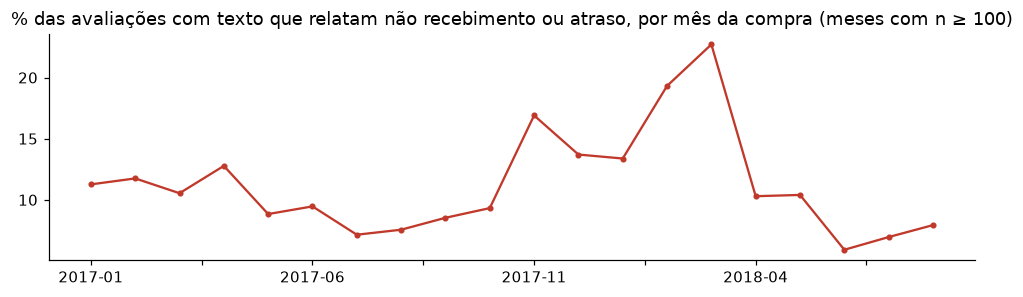

,% entrega,n
ano_mes,,
2018-03,22.7,3043
2018-02,19.3,2858
2017-11,16.9,3047
2017-12,13.7,2306
2018-01,13.4,2990


In [9]:
m = docs.assign(entrega=lab[["nao_recebido", "atraso"]].any(axis=1)).query("ano_mes >= '2017-01'")
g = m.groupby("ano_mes")["entrega"].agg(["mean", "size"])
g = g[g["size"] >= 100]  # meses com menos de 100 avaliações com texto ficam fora (percentual instável)
serie = g["mean"] * 100
ax = serie.plot(figsize=(9, 2.8), color="#c0392b", marker="o", ms=3)
ax.set_title("% das avaliações com texto que relatam não recebimento ou atraso, por mês da compra (meses com n ≥ 100)"); ax.set_xlabel("")
plt.tight_layout(); plt.show()
g.assign(pct=serie.round(1)).sort_values("pct", ascending=False).head(5)[["pct", "size"]].rename(columns={"pct": "% entrega", "size": "n"})

## 5. Perguntas agregadas respondidas pela camada analítica

In [10]:
rag = None
try:
    from voc_rag.pipeline import VoCRAG
    rag = VoCRAG(s)
except Exception as e:
    print("pipeline indisponível:", e)
if rag:
    r = rag.ask("Quais reclamações relacionadas à entrega aparecem com maior frequência?")
    display(Markdown(r.to_markdown()))

**Pergunta:** Quais reclamações relacionadas à entrega aparecem com maior frequência?

**Status:** `ok` · **modo:** `analitico`
**Filtros:** nenhum

Resumo: As principais reclamações relacionadas à entrega são sobre pedido não recebido (3406 avaliações, 23,6%) e pedido incompleto / faltando itens (1484 avaliações, 10,3%).
- Pedido não recebido (3406 avaliações, 23,6%): Os clientes relatam descaso e falta de compromisso devido ao produto não ter sido entregue ou nunca ter chegado [E1][E2].
- Pedido incompleto / faltando itens (1484 avaliações, 10,3%): Os consumidores apontam o recebimento de apenas parte dos produtos comprados, sem a entrega dos itens restantes ou devolução do valor [E3][E4].
- Atraso na entrega (1215 avaliações, 8,4%): Os relatos descrevem pedidos com entrega em atraso ou que continuam sendo aguardados [E5][E6].
- Transportadora / Correios (739 avaliações, 5,1%): Os clientes reclamam do serviço dos Correios, apontando falta de qualidade e atualizações de rastreamento que indicam saída para entrega sem que a tentativa real ocorra [E7][E8].

> Contagens calculadas sobre a base (98410 avaliações no recorte (42138 com comentário); filtros: nenhum).
> Método: taxonomia de temas por regras léxicas auditáveis; uma avaliação pode ter mais de um tema. Cobertura da taxonomia (problema): 41,7% das 14445 avaliações da base de contagem.

| rótulo | review_id | nota | compra | categoria | entrega | relevância | citada | texto |
|---|---|---|---|---|---|---|---|---|
| E1 | `4c2ab64ffc9119884d87d90bf9d630c3` | 1 | 2017-03 | sem_itens | nao_entregue | 0.080 | sim | Descaso com o cliente. O produto não foi entregue. |
| E2 | `4966a0af44d9ad8f87d9263c8bacc9dc` | 1 | 2017-10 | beleza_saude | atrasada | 0.039 | sim | Falta de compromisso com o cliente. O meu produto nunca chegou apesar das minhas reclamações. |
| E3 | `5148ad2bdca65375e9504355d79c6ad4` | 1 | 2018-07 | beleza_saude | no_prazo | 0.323 | sim | Entrega incompleta. Realizei um pedido com dois itens e apenas 1 deles foi entregue. Fiz algumas reclamações e até agora ninguém entrou em contato comigo pra entregar o outro produto ou para devolver o dinheiro. |
| E4 | `7d6ba969ba93e86ed87d563c1821616b` | 1 | 2018-08 | eletronicos | no_prazo | 0.081 | sim | Entrega faltando produtos. Fiz pedido de 6 produtos e só recebi 2. |
| E5 | `7528a396f7625967f05cb09946286608` | 1 | 2018-03 | construcao_ferramentas_construcao | atrasada | 0.040 | sim | Ultimamente estão atrasando muito as entregas |
| E6 | `364e74a2d89a35fa3fad2beaf96d8f17` | 1 | 2018-07 | moveis_escritorio | atrasada | 0.034 | sim | Aguardando a entrega. Entrega em atraso. |
| E7 | `3639b950e01dcb13e78d423d698e8b24` | 2 | 2018-06 | cama_mesa_banho | no_prazo | 0.070 | sim | Entrega complicada. Recomendo a loja, porém, a entrega pelo Correios está cada dia mais difícil. Ao rastrear o objeto aparece que o Correios saiu para entrega, sendo que na realidade não houve tentativa de entrega |
| E8 | `6d58ce34b52614647bda4b987b6193c9` | 3 | 2018-07 | moveis_decoracao | no_prazo | 0.028 | sim | entrega. Favor procurar utra transportadora...Correios sem qualidade. |

In [11]:
if rag:
    r = rag.ask("Quais são os principais problemas relatados nas avaliações com nota baixa de produtos de informática?")
    display(Markdown(r.to_markdown()))

**Pergunta:** Quais são os principais problemas relatados nas avaliações com nota baixa de produtos de informática?

**Status:** `ok` · **modo:** `analitico`
**Filtros:** nota 1–2; categoria ∈ {informatica_acessorios, pc_gamer, pcs}

Resumo: Os principais problemas relatados nas avaliações com nota baixa de produtos de informática são Pedido não recebido (197 avaliações, 23,4%) e Troca, devolução, cancelamento ou reembolso (124 avaliações, 14,7%).
- Pedido não recebido (197 avaliações, 23,4%): Clientes relatam que ainda estão aguardando o recebimento ou que o produto consta como entregue sem ter chegado [E1][E2].
- Troca, devolução, cancelamento ou reembolso (124 avaliações, 14,7%): Consumidores relatam solicitações de devolução por teclas que não funcionam e pedidos entregues mesmo após solicitação de cancelamento da compra [E3][E4].
- Pedido incompleto / faltando itens (95 avaliações, 11,3%): Os relatos apontam falta de itens no envio, como a entrega de apenas uma unidade quando foram compradas duas [E5][E6].
- Não recomenda / insatisfação geral (95 avaliações, 11,3%): Manifestações de insatisfação geral com o serviço, atraso na entrega, falta de contato e ausência de resposta a e-mails [E7][E8].
- Defeito / não funciona (87 avaliações, 10,3%): Clientes relatam produtos com defeito que não funcionam, como cartão de memória corrompido/não reconhecido e produto que não fornece a voltagem correta [E9][E10].

> Contagens calculadas sobre a base (1082 avaliações no recorte (842 com comentário); filtros: nota 1–2; categoria ∈ {informatica_acessorios, pc_gamer, pcs}).
> Método: taxonomia de temas por regras léxicas auditáveis; uma avaliação pode ter mais de um tema. Cobertura da taxonomia (problema): 73,2% das 842 avaliações da base de contagem.

| rótulo | review_id | nota | compra | categoria | entrega | relevância | citada | texto |
|---|---|---|---|---|---|---|---|---|
| E1 | `21e7202cb20e7a54e30b112d39452961` | 1 | 2018-04 | informatica_acessorios | nao_entregue | 0.046 | sim | Não recebi o produto. Aguardando ainda o recebimento do produto. |
| E2 | `bc2f89d98cee993d05d92e66984a32db` | 1 | 2018-01 | informatica_acessorios | no_prazo | 0.034 | sim | Desde que solucionem o meu problema, eu recomendaria pq consta que meu produto foi entre e ele ainda não chegou. |
| E3 | `bf04cefb8f9cac1da1988498fb888ad9` | 1 | 2018-01 | informatica_acessorios | no_prazo | 0.099 | sim | produto veio com teclas não funcionando, solicitei devolução |
| E4 | `a8221e7e9a7fe49195b4dd46044bcff1` | 1 | 2018-08 | informatica_acessorios | no_prazo | 0.098 | sim | cancelamento compra. Foi cancelado a compra antes da emissão de nota fiscal e mesmo assim entregaram o produto sem efetivar o cancelamento solicitado. |
| E5 | `a10cf8ce3a092c1af80f701d431c2c05` | 1 | 2018-03 | informatica_acessorios | no_prazo | 0.281 | sim | Faltou 1 produto. |
| E6 | `d79d0189204c6823102e894bdefb8703` | 1 | 2018-08 | pcs | no_prazo | 0.129 | sim | Não recebi tds os produto. Só recebi uma unidade sendo que comprei duas unidades |
| E7 | `309c96d9bc0ae61c36ab7e86d3f29feb` | 2 | 2018-04 | informatica_acessorios | no_prazo | 0.066 | sim | insatisfeito |
| E8 | `7a7a26eae4e8fe06bf3515cb8d8bca1b` | 1 | 2018-03 | informatica_acessorios | nao_entregue | 0.062 | sim | Empresa não entrega os produtos na data e não entra em contato com o cliente. Também não responde a os e-mails que já enviei para para o shop time. Péssima. |
| E9 | `dd093426fbb6f0b57411d21c0423a5c0` | 1 | 2018-05 | informatica_acessorios | no_prazo | 0.208 | sim | Produto com defeito. O cartão de memória não funciona. No celular ele aparece como corrompido e no computador ele nem é reconhecido. |
| E10 | `a58ead6f5717855da780960d415ed427` | 1 | 2018-07 | informatica_acessorios | no_prazo | 0.199 | sim | Produto com defeito. O produto não dá a voltagem correta impossibilitando o funcionamento do aparelho. |